In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve)
import shap

print("All libraries loaded!")


All libraries loaded!


In [2]:
# Load cleaned data
df = pd.read_csv('churn_cleaned.csv')

# Split features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")
print(f"Churn rate in train: {y_train.mean():.2%}")
print(f"Churn rate in test:  {y_test.mean():.2%}")

Training samples: 5625
Testing samples:  1407
Features: 30
Churn rate in train: 26.58%
Churn rate in test:  26.58%


In [3]:

# Handle class imbalance with scale_pos_weight
scale = (y_train == 0).sum() / (y_train == 1).sum()

# Train XGBoost
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale,  # handles imbalance
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)

model.fit(X_train, y_train)
print(f"Model trained! scale_pos_weight = {scale:.2f}")

C:\Users\sneha\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:40:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model trained! scale_pos_weight = 2.76


              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1033
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407

ROC-AUC Score: 0.8344


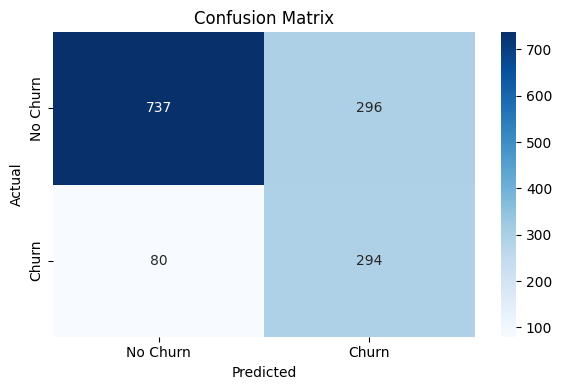

In [4]:
# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Classification report
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

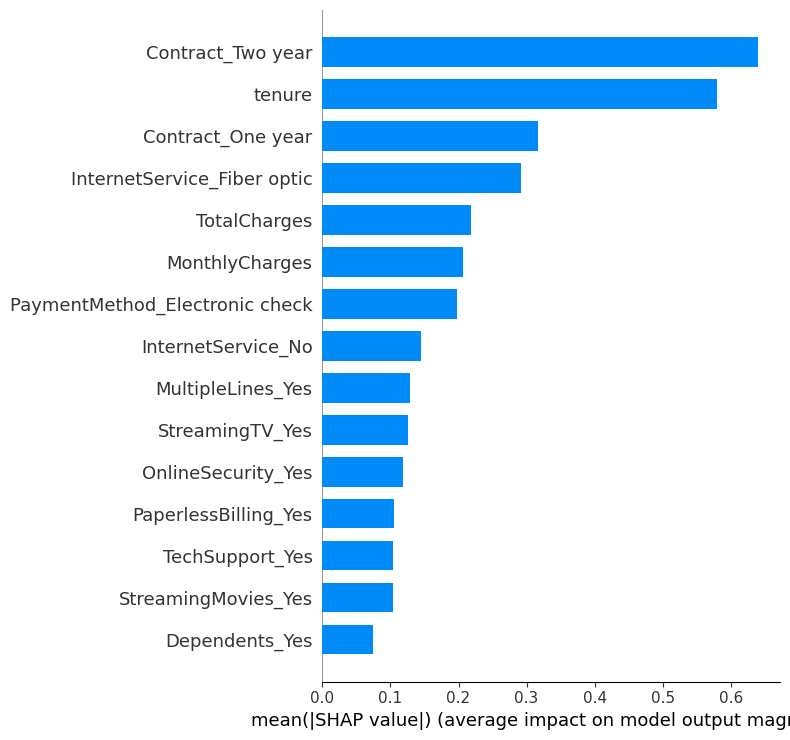

In [5]:
# SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15)

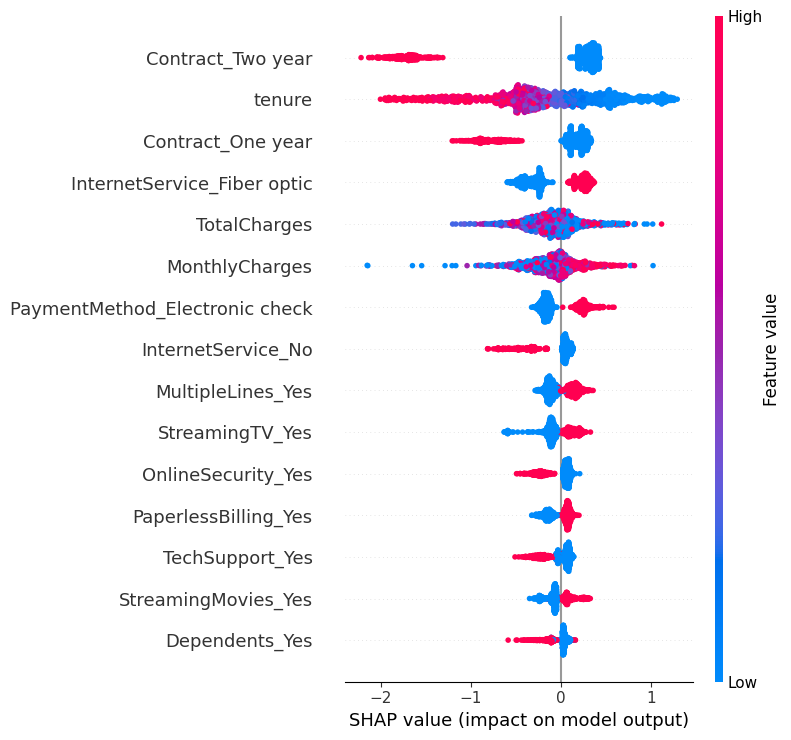

In [6]:
shap.summary_plot(shap_values, X_test, max_display=15)